In [9]:
#!/usr/bin/env python3
"""
Download Daymet gridded daily precipitation data from ORNL DAAC.

Spatially subsets data to the Skagit subbasins (Upper Skagit, Sauk, Lower Skagit).
Downloads data from 1981 to 2020 and saves to /data0/skagit_met/data_transfer/data/daymet_new_hq

Data source: https://data.ornldaac.earthdata.nasa.gov/protected/daymet/Daymet_Daily_V4R1/
Reference: https://daymet.ornl.gov/
"""

import os
import geopandas as gpd
import xarray as xr
import rioxarray
import requests
from tqdm import tqdm



In [10]:
# ============================================================================
# VARIABLES - Temporal subset
# ============================================================================
startyr = 1981
endyr = 1981

# ============================================================================
# VARIABLES - Region and variable
# ============================================================================
region = "na"  # North America
var = "prcp"   # Precipitation



In [11]:
# ============================================================================
# VARIABLES - Spatial subset - Get bounding box from Skagit subbasins
# ============================================================================
BASE_DIR = "/data0/hernanqd/plots_code/skagit_basin_de"
HUC8_GEO = os.path.join(BASE_DIR, "data/GIS/SkagitSubBasin_HUC8.geojson")
OUTPUT_DIR = "/data0/skagit_met/data_transfer/data/daymet_new_hq"

# ============================================================================
# Download Configuration
# ============================================================================
BASE_URL = "https://data.ornldaac.earthdata.nasa.gov/protected/daymet/Daymet_Daily_V4R1/data"

# Earthdata credentials
EDL_USERNAME = "hernanqd"
EDL_PASSWORD = "Uwashington13191017."

print("="*80)
print("DAYMET Direct Download Script with Subsetting")
print("="*80)



DAYMET Direct Download Script with Subsetting


In [12]:
# ============================================================================
# Read Skagit subbasin geometry
# ============================================================================
print("\nReading Skagit subbasin geometry...")
gdf = gpd.read_file(HUC8_GEO)

# Filter for the three subbasins
subbasins = ["Upper Skagit", "Sauk", "Lower Skagit"]
skagit_gdf = gdf[gdf["Name"].str.contains("|".join(subbasins), case=False, regex=True)]

if len(skagit_gdf) == 0:
    print(f"ERROR: Could not find subbasins: {subbasins}")
    exit(1)

print(f"Found {len(skagit_gdf)} subbasins:")
for idx, row in skagit_gdf.iterrows():
    print(f"  - {row['Name']}")

# Get combined bounding box
bounds = skagit_gdf.total_bounds  # [minx, miny, maxx, maxy]

north = bounds[3]  # maxy
south = bounds[1]  # miny
east = bounds[2]   # maxx
west = bounds[0]   # minx

print(f"\nBounding box:")
print(f"  North: {north:.6f}°")
print(f"  South: {south:.6f}°")
print(f"  East:  {east:.6f}°")
print(f"  West:  {west:.6f}°")

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"\nOutput directory: {OUTPUT_DIR}")




Reading Skagit subbasin geometry...
Found 3 subbasins:
  - Upper Skagit
  - Sauk
  - Lower Skagit

Bounding box:
  North: 49.313400°
  South: 47.957521°
  East:  -120.654609°
  West:  -122.538683°

Output directory: /data0/skagit_met/data_transfer/data/daymet_new_hq


In [13]:
# # ============================================================================
# # Download and subset data
# # ============================================================================
# print("\n" + "="*80)
# print("Downloading and subsetting data...")
# print("="*80 + "\n")

# downloaded = 0
# failed = 0
# failed_years = []

# # Set up authentication
# auth = (EDL_USERNAME, EDL_PASSWORD)

# # Main loop with progress bar
# for i in tqdm(range(startyr, endyr + 1), desc="Processing years", unit="year"):
#     # Construct download URL
#     filename = f"daymet_v4_daily_{region}_{var}_{i}.nc"
#     url = f"{BASE_URL}/{filename}"
#     temp_file = os.path.join(OUTPUT_DIR, f"temp_{filename}")
#     output_file = os.path.join(OUTPUT_DIR, f"{var}_{i}_subset.nc")

#     try:
#         # Download file with progress bar
#         response = requests.get(url, auth=auth, stream=True)
#         response.raise_for_status()

#         # Get total file size
#         total_size = int(response.headers.get('content-length', 0))

#         with open(temp_file, 'wb') as f:
#             with tqdm(total=total_size, unit='B', unit_scale=True, leave=False, desc=f"  Downloading {filename}") as pbar:
#                 for chunk in response.iter_content(chunk_size=8192):
#                     f.write(chunk)
#                     pbar.update(len(chunk))

# #         # Subset spatially to bounding box
# #         with tqdm(total=1, unit=" ", leave=False, desc=f"  Subsetting {filename}") as pbar:
# #             ds = xr.open_dataset(temp_file)

# #             # Find the actual coordinate names (could be lon/lat or x/y)
# #             lat_coord = None
# #             lon_coord = None
# #             for coord_name in ds.coords:
# #                 if 'lat' in coord_name.lower():
# #                     lat_coord = coord_name
# #                 if 'lon' in coord_name.lower():
# #                     lon_coord = coord_name

# #             if lat_coord and lon_coord:
# #                 # Subset using actual coordinate names
# #                 ds_subset = ds.sel({
# #                     lon_coord: slice(west, east),
# #                     lat_coord: slice(south, north)
# #                 })
# #             else:
# #                 # Fallback to x/y if available
# #                 ds_subset = ds.sel(x=slice(west, east), y=slice(south, north))

# #             # Save subsetted file
# #             ds_subset.to_netcdf(output_file)
# #             ds.close()
# #             ds_subset.close()
# #             pbar.update(1)

# #         # Remove temporary file
# #         os.remove(temp_file)
# #         downloaded += 1

#     except requests.exceptions.HTTPError as e:
#         if e.response.status_code == 404:
#             tqdm.write(f"  ✗ Year {i}: File not found (404)")
#         else:
#             tqdm.write(f"  ✗ Year {i}: HTTP Error {e.response.status_code}")
#         failed += 1
#         failed_years.append(i)
#         if os.path.exists(temp_file):
#             os.remove(temp_file)
#     except Exception as e:
#         tqdm.write(f"  ✗ Year {i}: {str(e)[:60]}")
#         failed += 1
#         failed_years.append(i)
#         if os.path.exists(temp_file):
#             os.remove(temp_file)

# print("\n" + "="*80)
# print("Download and subset complete!")
# print("="*80)
# print(f"Successfully processed: {downloaded} files")
# print(f"Failed: {failed} files")
# print(f"Total years: {endyr - startyr + 1}")

# if failed_years:
#     print(f"\nFailed years: {failed_years}")

# print(f"\nData saved to: {OUTPUT_DIR}")


In [14]:
ds = xr.open_dataset("/data0/skagit_met/data_transfer/data/daymet_new_hq/prcp_2020_subset.nc")
ds

<xarray.Dataset> Size: 250MB
Dimensions:                  (time: 365, y: 173, x: 165, nv: 2)
Coordinates:
  * time                     (time) datetime64[ns] 3kB 2020-01-01T12:00:00 .....
  * y                        (y) float32 692B 9.33e+05 9.32e+05 ... 7.61e+05
  * x                        (x) float32 660B -1.59e+06 ... -1.426e+06
    lat                      (y, x) float32 114kB ...
    lon                      (y, x) float32 114kB ...
Dimensions without coordinates: nv
Data variables:
    yearday                  (time, y, x) float32 42MB ...
    time_bnds                (time, nv, y, x) datetime64[ns] 167MB ...
    lambert_conformal_conic  (y, x) float32 114kB ...
    prcp                     (time, y, x) float32 42MB ...
Attributes:
    start_year:        2020
    source:            Daymet Software Version 4.0
    Version_software:  Daymet Software Version 4.0
    Version_data:      Daymet Data Version 4.0
    Conventions:       CF-1.6
    citation:          Please see http://daymet.ornl.gov/ for current Daymet ...
    references:        Please see http://daymet.ornl.gov/ for current informa...

In [15]:
# temp_file

In [16]:
# import xarray as xr

# # Open the full file
# ds = xr.open_dataset('/data0/skagit_met/data_transfer/data/daymet_new_hq/temp_daymet_v4_daily_na_prcp_1981.nc')

# # Subset when you actually need it for analysis
# north = 49.313400
# south = 47.957521
# east = -120.654609
# west = -122.538683

# # Use lat/lon directly
# ds_subset = ds.where(
#     (ds['lat'] >= south) & (ds['lat'] <= north) & 
#     (ds['lon'] >= west) & (ds['lon'] <= east),
#     drop=True
# )

# # Now use ds_subset for your analysis
# print(ds_subset)

In [17]:
ds_subset = xr.open_dataset("/data0/skagit_met/data_transfer/data/daymet_new_hq/prcp_2010_subset.nc")
ds_subset

<xarray.Dataset> Size: 250MB
Dimensions:                  (time: 365, y: 173, x: 165, nv: 2)
Coordinates:
  * time                     (time) datetime64[ns] 3kB 2010-01-01T12:00:00 .....
  * y                        (y) float32 692B 9.33e+05 9.32e+05 ... 7.61e+05
  * x                        (x) float32 660B -1.59e+06 ... -1.426e+06
    lat                      (y, x) float32 114kB ...
    lon                      (y, x) float32 114kB ...
Dimensions without coordinates: nv
Data variables:
    yearday                  (time, y, x) float32 42MB ...
    time_bnds                (time, nv, y, x) datetime64[ns] 167MB ...
    lambert_conformal_conic  (y, x) float32 114kB ...
    prcp                     (time, y, x) float32 42MB ...
Attributes:
    start_year:        2010
    source:            Daymet Software Version 4.0
    Version_software:  Daymet Software Version 4.0
    Version_data:      Daymet Data Version 4.0
    Conventions:       CF-1.6
    citation:          Please see http://daymet.ornl.gov/ for current Daymet ...
    references:        Please see http://daymet.ornl.gov/ for current informa...

In [18]:
# Check for NaN values in the sliced data
nan_count = ds_subset['prcp'].isnull().sum().values
total_count = ds_subset['prcp'].size
nan_percentage = (nan_count / total_count * 100)

print(f"Total cells: {total_count}")
print(f"NaN cells: {nan_count}")
print(f"NaN percentage: {nan_percentage:.2f}%")

# Check coordinate ranges
print(f"\nLat range: {ds_subset['lat'].min().values:.4f} to {ds_subset['lat'].max().values:.4f}")
print(f"Lon range: {ds_subset['lon'].min().values:.4f} to {ds_subset['lon'].max().values:.4f}")

# Compare to requested bounds
print(f"\nRequested bounds:")
print(f"Lat: {south} to {north}")
print(f"Lon: {west} to {east}")

Total cells: 10418925
NaN cells: 3524805
NaN percentage: 33.83%

Lat range: 47.6500 to 49.6058
Lon range: -123.0597 to -120.1894

Requested bounds:
Lat: 47.9575212860088 to 49.3133996542101
Lon: -122.538683360485 to -120.654609352862


In [19]:
ds_subset

<xarray.Dataset> Size: 250MB
Dimensions:                  (time: 365, y: 173, x: 165, nv: 2)
Coordinates:
  * time                     (time) datetime64[ns] 3kB 2010-01-01T12:00:00 .....
  * y                        (y) float32 692B 9.33e+05 9.32e+05 ... 7.61e+05
  * x                        (x) float32 660B -1.59e+06 ... -1.426e+06
    lat                      (y, x) float32 114kB 49.21 49.21 ... 48.04 48.04
    lon                      (y, x) float32 114kB -123.1 -123.0 ... -120.2
Dimensions without coordinates: nv
Data variables:
    yearday                  (time, y, x) float32 42MB ...
    time_bnds                (time, nv, y, x) datetime64[ns] 167MB ...
    lambert_conformal_conic  (y, x) float32 114kB ...
    prcp                     (time, y, x) float32 42MB nan nan nan ... nan nan
Attributes:
    start_year:        2010
    source:            Daymet Software Version 4.0
    Version_software:  Daymet Software Version 4.0
    Version_data:      Daymet Data Version 4.0
    Conventions:       CF-1.6
    citation:          Please see http://daymet.ornl.gov/ for current Daymet ...
    references:        Please see http://daymet.ornl.gov/ for current informa...

In [20]:
# Check the bounds of both datasets
print("Data bounds (x):", prcp_first_day.x.min().values, "to", prcp_first_day.x.max().values)
print("Data bounds (y):", prcp_first_day.y.min().values, "to", prcp_first_day.y.max().values)

print("\nSubbasin bounds:")
print(skagit_gdf.bounds)
print("\nSubbasin total bounds:", skagit_gdf.total_bounds)

NameError: name 'prcp_first_day' is not defined

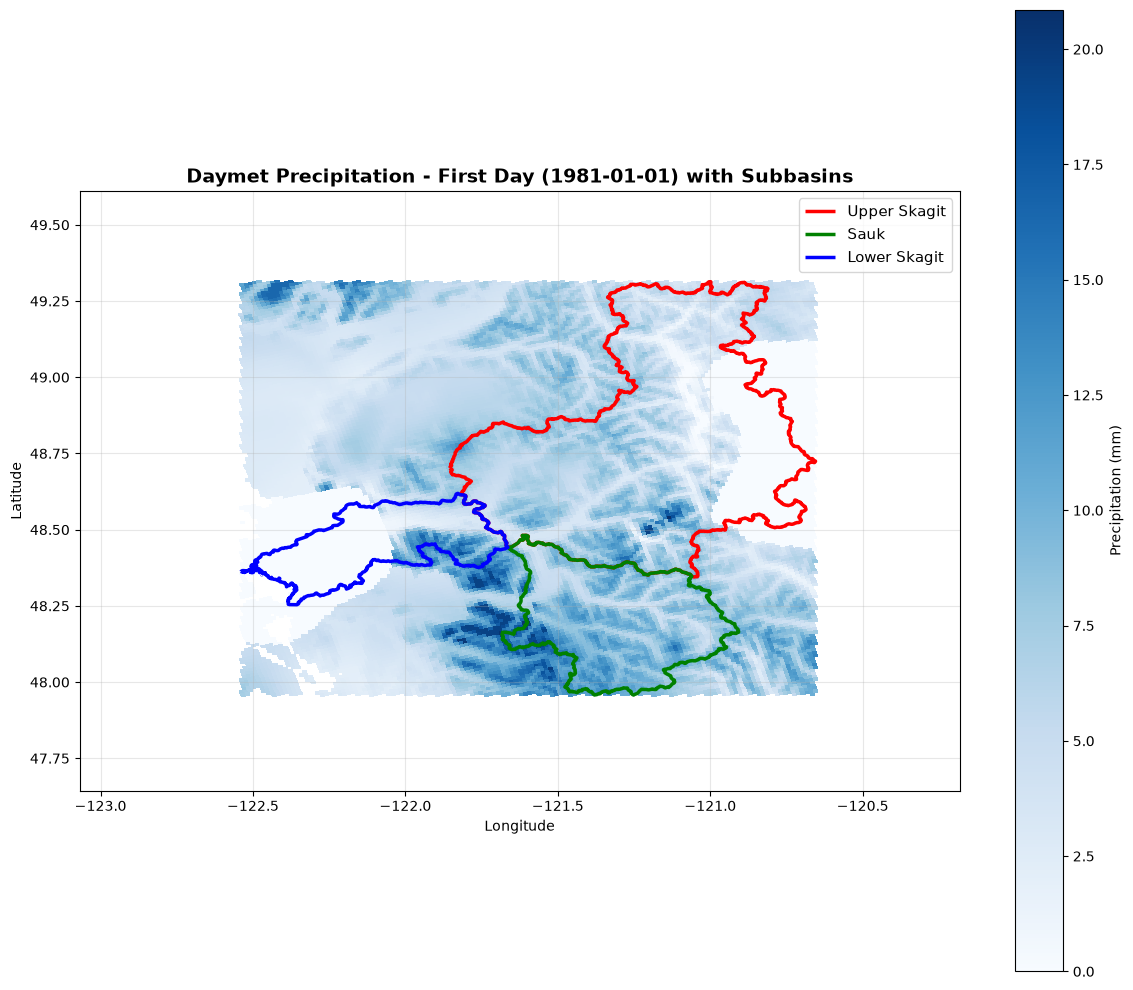

In [21]:
import matplotlib.pyplot as plt
import geopandas as gpd
import os
import numpy as np

# Get first day of precipitation
prcp_first_day = ds_subset['prcp'].isel(time=55)

# Get lat/lon coordinates from the data
lat = ds_subset['lat'].values
lon = ds_subset['lon'].values

# Load subbasins (keep in geographic coordinates)
BASE_DIR = "/data0/hernanqd/plots_code/skagit_basin_de"
HUC8_GEO = os.path.join(BASE_DIR, "data/GIS/SkagitSubBasin_HUC8.geojson")
gdf = gpd.read_file(HUC8_GEO)

# Filter for three subbasins
subbasins = ["Upper Skagit", "Sauk", "Lower Skagit"]
skagit_gdf = gdf[gdf["Name"].str.contains("|".join(subbasins), case=False, regex=True)]

# Create figure
fig, ax = plt.subplots(figsize=(12, 10))

# Plot precipitation using lat/lon instead of projected coordinates
prcp_first_day.plot.pcolormesh(
    ax=ax,
    x='lon',
    y='lat',
    cmap='Blues',
    cbar_kwargs={'label': 'Precipitation (mm)'}
)

# Plot subbasin boundaries (in geographic coordinates)
colors = ['red', 'green', 'blue']
for (idx, row), color in zip(skagit_gdf.iterrows(), colors):
    gpd.GeoSeries([row.geometry]).boundary.plot(
        ax=ax,
        color=color,
        linewidth=2.5,
        label=row['Name']
    )

ax.set_title('Daymet Precipitation - First Day (1981-01-01) with Subbasins', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(loc='upper right', fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
subseted_ds = xr.open_dataset("//data0/skagit_met/data_transfer/data/daymet_new_hq/prcp_2010_subset.nc")
subseted_ds

<xarray.Dataset> Size: 250MB
Dimensions:                  (time: 365, y: 173, x: 165, nv: 2)
Coordinates:
  * time                     (time) datetime64[ns] 3kB 2010-01-01T12:00:00 .....
  * y                        (y) float32 692B 9.33e+05 9.32e+05 ... 7.61e+05
  * x                        (x) float32 660B -1.59e+06 ... -1.426e+06
    lat                      (y, x) float32 114kB ...
    lon                      (y, x) float32 114kB ...
Dimensions without coordinates: nv
Data variables:
    yearday                  (time, y, x) float32 42MB ...
    time_bnds                (time, nv, y, x) datetime64[ns] 167MB ...
    lambert_conformal_conic  (y, x) float32 114kB ...
    prcp                     (time, y, x) float32 42MB ...
Attributes:
    start_year:        2010
    source:            Daymet Software Version 4.0
    Version_software:  Daymet Software Version 4.0
    Version_data:      Daymet Data Version 4.0
    Conventions:       CF-1.6
    citation:          Please see http://daymet.ornl.gov/ for current Daymet ...
    references:        Please see http://daymet.ornl.gov/ for current informa...

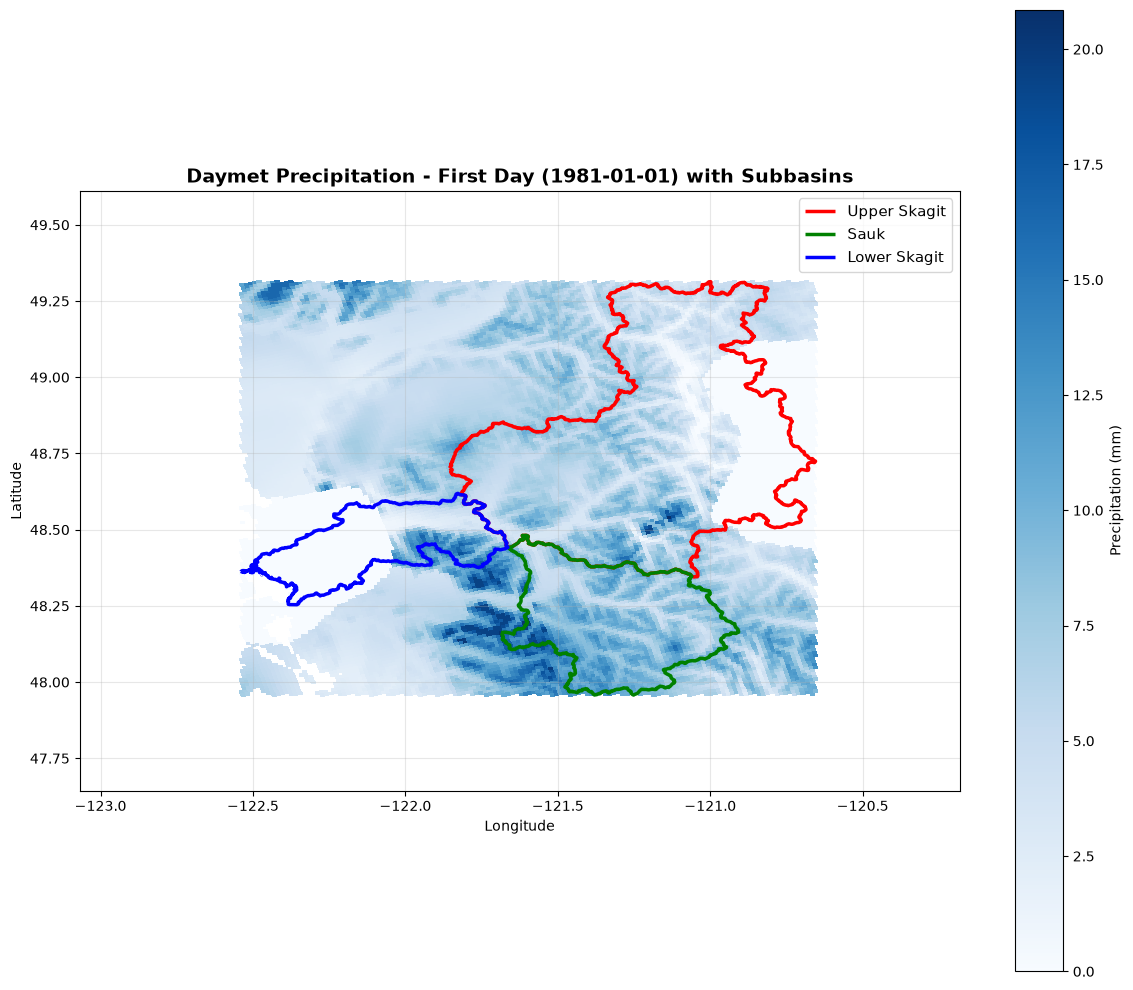

In [23]:
# Get first day of precipitation
prcp_first_day = subseted_ds['prcp'].isel(time=55)

# Get lat/lon coordinates from the data
lat = subseted_ds['lat'].values
lon = subseted_ds['lon'].values

# Load subbasins (keep in geographic coordinates)
BASE_DIR = "/data0/hernanqd/plots_code/skagit_basin_de"
HUC8_GEO = os.path.join(BASE_DIR, "data/GIS/SkagitSubBasin_HUC8.geojson")
gdf = gpd.read_file(HUC8_GEO)

# Filter for three subbasins
subbasins = ["Upper Skagit", "Sauk", "Lower Skagit"]
skagit_gdf = gdf[gdf["Name"].str.contains("|".join(subbasins), case=False, regex=True)]

# Create figure
fig, ax = plt.subplots(figsize=(12, 10))

# Plot precipitation using lat/lon instead of projected coordinates
prcp_first_day.plot.pcolormesh(
    ax=ax,
    x='lon',
    y='lat',
    cmap='Blues',
    cbar_kwargs={'label': 'Precipitation (mm)'}
)

# Plot subbasin boundaries (in geographic coordinates)
colors = ['red', 'green', 'blue']
for (idx, row), color in zip(skagit_gdf.iterrows(), colors):
    gpd.GeoSeries([row.geometry]).boundary.plot(
        ax=ax,
        color=color,
        linewidth=2.5,
        label=row['Name']
    )

ax.set_title('Daymet Precipitation - First Day (1981-01-01) with Subbasins', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(loc='upper right', fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()